In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LogLocator
from matplotlib.colors import (ListedColormap, LinearSegmentedColormap,
                               Normalize, LogNorm, TwoSlopeNorm, to_rgb)
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats, signal, optimize, integrate
from pathlib import Path
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ----------------------------------------------------------------------------
# Font resolution
# ----------------------------------------------------------------------------
FONT_STACK = [
    'Helvetica Neue', 'HelveticaNeue', 'Helvetica',   # macOS
    'TeX Gyre Heros', 'Nimbus Sans', 'FreeSans',      # Helvetica metric clones
    'Arial', 'Liberation Sans',                       # Windows / Linux
    'DejaVu Sans',                                    # matplotlib's own fallback
]

def resolve_font(stack=FONT_STACK, verbose=True):
    '''Return the first font in `stack` that is actually installed.'''
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in stack:
        if name in have:
            if verbose and name != stack[0]:
                print(f'[style] "{stack[0]}" not found -> using "{name}"')
            elif verbose:
                print(f'[style] using "{name}"')
            return name
    if verbose:
        print('[style] nothing in the stack found -> DejaVu Sans')
    return 'DejaVu Sans'

ACTIVE_FONT = resolve_font()

# ----------------------------------------------------------------------------
# House style
# ----------------------------------------------------------------------------
def set_style(base=11, family=None, mathfont='cm', usetex=False,
              screen_dpi=140, save_dpi=600):
    '''
    Apply the group house style.

    base       : point size of tick labels. Axis labels are base+3.
                 Journals want >= 6 pt after reduction; 8-11 pt is the sweet spot.
    mathfont   : 'cm'   -> Computer Modern math (matches a LaTeX manuscript)
                 'stix' -> Times-like math
                 'dejavusans' / 'custom' -> sans-serif math (matches Helvetica)
    usetex     : True routes ALL text through a real LaTeX install. Prettiest
                 and most consistent, but slow and breaks on machines without
                 LaTeX. Keep False for exploration, flip True for final figures.
    save_dpi   : only affects raster elements (imshow, scatter with many points).
                 Vector output is resolution-independent.
    '''
    mpl.rcParams.update(mpl.rcParamsDefault)
    fam = family or ACTIVE_FONT
    mpl.rcParams.update({
        # --- typography ---
        'font.family'       : 'sans-serif',
        'font.sans-serif'   : [fam] + FONT_STACK,
        'mathtext.fontset'  : mathfont,
        'mathtext.default'  : 'it',
        'text.usetex'       : usetex,
        'font.size'         : base,
        'axes.labelsize'    : base + 3,
        'axes.titlesize'    : base + 1,
        'axes.titleweight'  : 'regular',
        'xtick.labelsize'   : base,
        'ytick.labelsize'   : base,
        'legend.fontsize'   : base - 1,
        'legend.title_fontsize': base - 1,

        # --- axes furniture ---
        'axes.linewidth'    : 0.8,
        'axes.labelpad'     : 4.0,
        'axes.spines.top'   : False,
        'axes.spines.right' : False,
        'axes.axisbelow'    : True,
        'axes.grid'         : False,
        'grid.linewidth'    : 0.5,
        'grid.alpha'        : 0.35,

        # --- ticks: outward, minor ticks on ---
        'xtick.direction'   : 'out',   'ytick.direction'   : 'out',
        'xtick.major.size'  : 3.5,     'ytick.major.size'  : 3.5,
        'xtick.major.width' : 0.8,     'ytick.major.width' : 0.8,
        'xtick.minor.size'  : 2.0,     'ytick.minor.size'  : 2.0,
        'xtick.minor.width' : 0.6,     'ytick.minor.width' : 0.6,
        'xtick.major.pad'   : 3.0,     'ytick.major.pad'   : 3.0,

        # --- data elements ---
        'lines.linewidth'   : 1.4,
        'lines.markersize'  : 4.5,
        'lines.markeredgewidth': 0.6,
        'lines.solid_capstyle' : 'round',
        'patch.linewidth'   : 0.6,
        'errorbar.capsize'  : 2.5,
        'image.cmap'        : 'viridis',
        'image.interpolation': 'nearest',

        # --- legend ---
        'legend.frameon'      : False,
        'legend.handlelength' : 1.5,
        'legend.handletextpad': 0.5,
        'legend.labelspacing' : 0.30,
        'legend.borderpad'    : 0.2,
        'legend.columnspacing': 1.0,

        # --- figure / export ---
        'figure.facecolor'  : 'white',
        'axes.facecolor'    : 'white',
        'figure.dpi'        : screen_dpi,   # on-screen preview only
        'savefig.dpi'       : save_dpi,     # written files
        'savefig.bbox'      : 'tight',
        'savefig.pad_inches': 0.02,
        'savefig.facecolor' : 'white',
        'pdf.fonttype'      : 42,     # TrueType -> editable text in Illustrator
        'ps.fonttype'       : 42,
        'svg.fonttype'      : 'none', # keep <text> elements, do not outline
        'pdf.compression'   : 6,
    })

set_style()

# ----------------------------------------------------------------------------
# Journal column widths (inches). Draw at the size you will print at.
# ----------------------------------------------------------------------------
W = {
    'prl_single' : 3.375,   # Phys. Rev. Lett. / APS single column
    'prl_double' : 6.75,
    'nature_1col': 3.504,   # 89 mm
    'nature_2col': 7.205,   # 183 mm
    'pnas_1col'  : 3.42,
    'pnas_2col'  : 7.0,
    'elsevier_1col': 3.543, # 90 mm
    'elsevier_2col': 7.480, # 190 mm
    'jfm'        : 5.31,    # J. Fluid Mech. text width
    'beamer'     : 4.5,
}
print(f'[style] active font: {ACTIVE_FONT}')

[style] using "Helvetica Neue"
[style] active font: Helvetica Neue


# MODIFIED EXPERIMENT



In [2]:

import numpy as np


def generate_samples(r, N=50000, T=20):
    """
    Generate N independent AR(1) trajectories of length T.

    Each trajectory X^(n) = (x_0, ..., x_{T-1})
    is treated as one vector in R^T.
    """

    # Critical point: r_c = 0
    # a(r) -> 1 as r -> 0
    a = np.exp(-r)

    # Relaxation time
    tau = -1.0 / np.log(a)

    X = np.zeros((N, T))

    # Generate independent trajectories
    X[:, 0] = np.random.randn(N)

    for t in range(1, T):
        X[:, t] = a * X[:, t-1] + np.random.randn(N)

    return X, tau



In [3]:

def covariance(r, N=50000, T=20):
    X, tau = generate_samples(r, N=N, T=T)

    # Rows = independent trajectories
    # Columns = time coordinates
    Sigma = np.cov(X, rowvar=False)

    return Sigma, tau


In [4]:

r_list = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 5e-3, 1e-3, 5e-4, 1e-4]


In [5]:

for r in r_list:

    Sigma, tau = covariance(r)

    eigvals = np.linalg.eigvalsh(Sigma)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"lambda_max={eigvals[-1]:.3f}, "
        f"lambda_2={eigvals[-2]:.3f}"
    )


r=0.5, tau=2.00, lambda_max=6.008, lambda_2=4.921
r=0.2, tau=5.00, lambda_max=21.851, lambda_2=11.262
r=0.1, tau=10.00, lambda_max=48.423, lambda_2=15.443
r=0.05, tau=20.00, lambda_max=84.779, lambda_2=17.525
r=0.02, tau=50.00, lambda_max=126.464, lambda_2=18.604
r=0.01, tau=100.00, lambda_max=145.625, lambda_2=19.002
r=0.005, tau=200.00, lambda_max=157.628, lambda_2=19.073
r=0.001, tau=1000.00, lambda_max=167.377, lambda_2=19.063
r=0.0005, tau=2000.00, lambda_max=168.544, lambda_2=19.092
r=0.0001, tau=10000.00, lambda_max=170.550, lambda_2=19.183


In [6]:

for r in r_list:

    Sigma, tau = covariance(r)

    eigvals, eigvecs = np.linalg.eigh(Sigma)

    lam1 = eigvals[-1]
    lam2 = eigvals[-2]

    explained = lam1 / np.sum(eigvals)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"lambda1/lambda2={lam1/lam2:.2f}, "
        f"variance fraction={explained:.3f}"
    )

Sigma_ref, tau = covariance(1e-4)

evals, evecs = np.linalg.eigh(Sigma_ref)
v_ref = evecs[:, -1]


r=0.5, tau=2.00, lambda1/lambda2=1.20, variance fraction=0.195
r=0.2, tau=5.00, lambda1/lambda2=1.96, variance fraction=0.402
r=0.1, tau=10.00, lambda1/lambda2=3.17, variance fraction=0.570
r=0.05, tau=20.00, lambda1/lambda2=4.81, variance fraction=0.687
r=0.02, tau=50.00, lambda1/lambda2=6.74, variance fraction=0.762
r=0.01, tau=100.00, lambda1/lambda2=7.66, variance fraction=0.784
r=0.005, tau=200.00, lambda1/lambda2=8.36, variance fraction=0.800
r=0.001, tau=1000.00, lambda1/lambda2=8.87, variance fraction=0.810
r=0.0005, tau=2000.00, lambda1/lambda2=9.02, variance fraction=0.813
r=0.0001, tau=10000.00, lambda1/lambda2=8.85, variance fraction=0.810


In [7]:

for r in r_list:

    Sigma, tau = covariance(r)

    evals, evecs = np.linalg.eigh(Sigma)
    v = evecs[:, -1]

    overlap = abs(v @ v_ref)

    print(
        f"r={r:.3g}, "
        f"tau={tau:.2f}, "
        f"overlap={overlap:.4f}"
    )

r=0.5, tau=2.00, overlap=0.9242
r=0.2, tau=5.00, overlap=0.9666
r=0.1, tau=10.00, overlap=0.9844
r=0.05, tau=20.00, overlap=0.9954
r=0.02, tau=50.00, overlap=0.9994
r=0.01, tau=100.00, overlap=0.9998
r=0.005, tau=200.00, overlap=1.0000
r=0.001, tau=1000.00, overlap=1.0000
r=0.0005, tau=2000.00, overlap=1.0000
r=0.0001, tau=10000.00, overlap=1.0000


# <fieldset>COMPUTATIONAL RESULTS</fieldset>

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
font = {
        'weight' : 'light',
        'size'   : 16}

mpl.rc('font', **font)
plt.rc("xtick", labelsize="medium")
rc = {"mathtext.fontset" : "cm"}
plt.rcParams.update(rc)

# =====================================================
# Configuration
# =====================================================

N_train = 50000

nu_list = [ 0.35,0.55, 0.75]

Delta_list = np.logspace(-6, -3, 20)

degree_list = [
    2,
    4,
    6,
    8,
    10,
    16
]

r_min = -2.0
r_max = 2.0

N_plot = 20000

# =====================================================
# Critical function
# =====================================================

def lam(r, nu):
    return np.abs(r) ** (-nu)

def g(r, nu):
    return np.abs(r)**nu/(1.0 + np.abs(r)**nu)

# =====================================================
# Main sweep
# =====================================================

results = []

for nu in nu_list:

    for Delta in Delta_list:

        # ---------------------------
        # Training samples
        # ---------------------------

        r_left = np.random.uniform(
            r_min,
            -Delta/2,
            N_train // 2
        )

        r_right = np.random.uniform(
            Delta/2,
            r_max,
            N_train // 2
        )

        r_train = np.concatenate(
            [r_left, r_right]
        )

        y_train = g(r_train, nu)

        # score-loss-inspired weight
        weights = 1.0 + lam(r_train, nu)

        # evaluation grid

        r_plot = np.linspace(
            r_min,
            r_max,
            N_plot
        )

        y_true = g(r_plot, nu)

        train_mask = np.abs(r_plot) > Delta/2
        crit_mask = np.abs(r_plot) < Delta/2

        for degree in degree_list:

            # -----------------------
            # Fit polynomial
            # -----------------------

            coeffs = np.polyfit(
                r_train,
                y_train,
                degree,
                w=np.sqrt(weights)
            )

            leading_coeff = coeffs[0]
            const_coeff = coeffs[-1]

            poly = np.poly1d(coeffs)

            y_pred = poly(r_plot)

            plot_weights = 1 + lam(r_plot, nu)

            # -----------------------
            # Errors
            # -----------------------

            train_mse = np.mean(
                plot_weights[train_mask] * (
                    y_true[train_mask]
                    - y_pred[train_mask]
                ) ** 2
            )

            r_crit = np.linspace(-Delta/2, Delta/2, N_plot)

            critical_mse = np.mean(
                (1 + lam(r_crit, nu)) * (
                    g(r_crit, nu)
                    - poly(r_crit)
                )**2
            )

            gap_ratio = (
                critical_mse
                / train_mse
            )

            results.append(
                {
                    "nu": nu,
                    "Delta": Delta,
                    "degree": degree,
                    "train_mse": train_mse,
                    "critical_mse": critical_mse,
                    "gap_ratio": gap_ratio,
                    "coeffs": coeffs.copy()
                }
            )
        # plt.figure()
        # plt.plot(r_plot,y_true)
        # plt.plot(r_plot, y_pred)
        # # plt.axvspan(-Delta/2,Delta/2, alpha = 0.3, label = 'excised gap')
        # # plt.legend()
        # # plt.xlim(-Delta*100, Delta * 100)
        # plt.xlabel('r')
        # plt.ylabel('g(r)')
        # plt.title(fr'$\Delta$:{Delta:.2e}, $\nu$:{nu:.2e}, K:{degree}')
        # plt.show()

# =====================================================
# Print table
# =====================================================

for r in results:

    print(
        f"nu={r['nu']:4.2f} "
        f"Delta={r['Delta']:.3e} "
        f"K={r['degree']:2d} "
        f"train={r['train_mse']:.3e} "
        f"critical={r['critical_mse']:.3e} "
        f"ratio={r['gap_ratio']:.3e}"
        f"coeff = {r['coeffs']}"
    )

nu=0.35 Delta=1.000e-06 K= 2 train=9.901e-03 critical=3.533e+01 ratio=3.569e+03coeff = [6.30322787e-02 2.54359296e-05 3.81689501e-01]
nu=0.35 Delta=1.000e-06 K= 4 train=6.229e-03 critical=2.873e+01 ratio=4.612e+03coeff = [-3.39846154e-02  9.47399876e-05  1.75165541e-01 -2.73752930e-04
  3.44559755e-01]
nu=0.35 Delta=1.000e-06 K= 6 train=4.486e-03 critical=2.477e+01 ratio=5.521e+03coeff = [ 2.32277633e-02 -1.14954847e-04 -1.58025887e-01  6.26761171e-04
  3.33040660e-01 -7.85419756e-04  3.20239361e-01]
nu=0.35 Delta=1.000e-06 K= 8 train=3.476e-03 critical=2.205e+01 ratio=6.344e+03coeff = [-1.76350756e-02  5.73779433e-05  1.53045712e-01 -4.80720429e-04
 -4.50442146e-01  1.24684527e-03  5.35075491e-01 -9.68376100e-04
  3.02353409e-01]
nu=0.35 Delta=1.000e-06 K=10 train=2.819e-03 critical=2.003e+01 ratio=7.106e+03coeff = [ 1.41176137e-02 -7.25388561e-05 -1.49949894e-01  7.18937032e-04
  5.81963622e-01 -2.43147357e-03 -1.00729652e+00  3.20159453e-03
  7.78379226e-01 -1.29639805e-03  2.883879

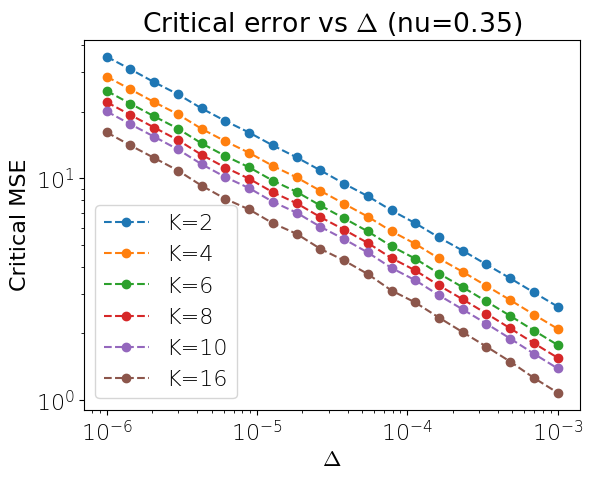

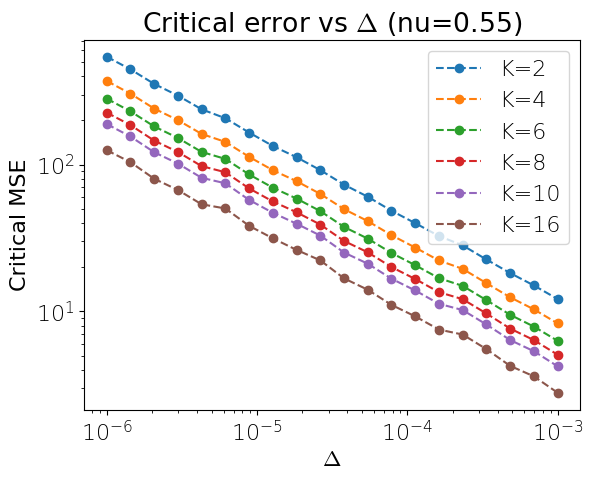

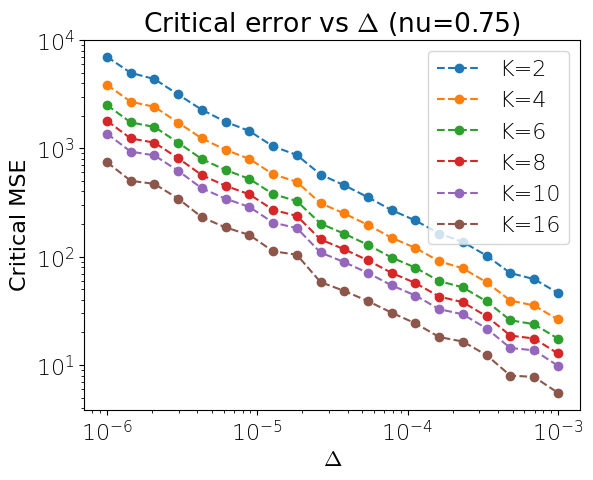

In [21]:
for nu in nu_list:

    plt.figure()

    for degree in degree_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["critical_mse"])

        plt.loglog(
            xs,
            ys,
            linestyle = '--',
            marker="o",
            label=f"K={degree}"
        )

    plt.title(
        fr"Critical error vs $\Delta$ (nu={nu})"
    )
    plt.xlabel(r"$\Delta$")
    plt.ylabel("Critical MSE")
    plt.legend()
    plt.show()

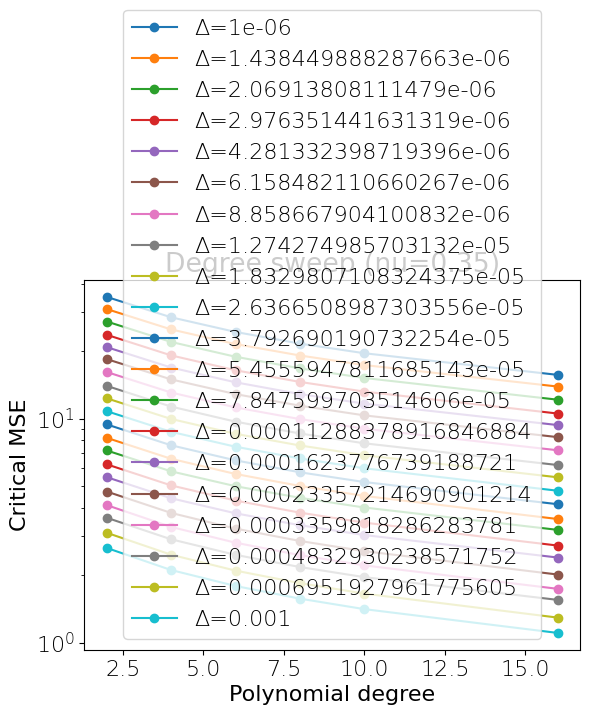

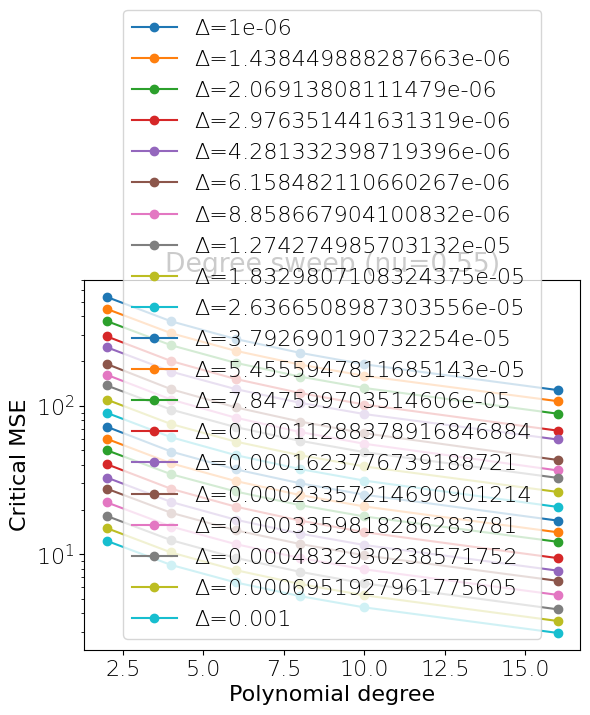

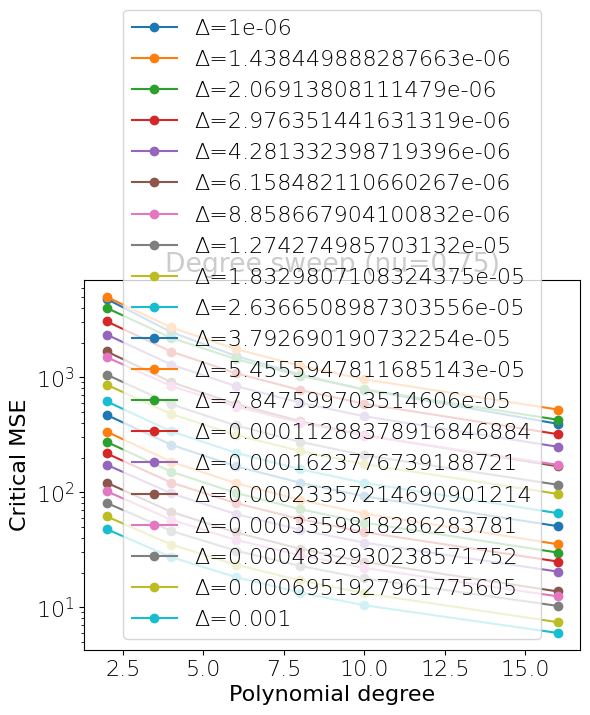

In [10]:
for nu in nu_list:

    plt.figure()

    for Delta in Delta_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["Delta"] == Delta
            ):
                xs.append(r["degree"])
                ys.append(r["critical_mse"])

        plt.semilogy(
            xs,
            ys,
            marker="o",
            label=f"Δ={Delta}"
        )

    plt.xlabel("Polynomial degree")
    plt.ylabel("Critical MSE")
    plt.title(
        f"Degree sweep (nu={nu})"
    )
    plt.legend()
    plt.show()

In [22]:
for nu in nu_list:

    plt.figure(figsize=(7,5))

    for degree in degree_list:

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["leading_coeff"])

        order = np.argsort(xs)

        xs = np.array(xs)[order]
        ys = np.array(ys)[order]

        plt.plot(
            xs,
            ys,
            marker="o",
            label=f"K={degree}"
        )

    plt.xlabel(r"$\Delta$")
    plt.ylabel(r"$a_K$")
    plt.title(
        f"Signed leading coefficient (nu={nu})"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

KeyError: 'leading_coeff'

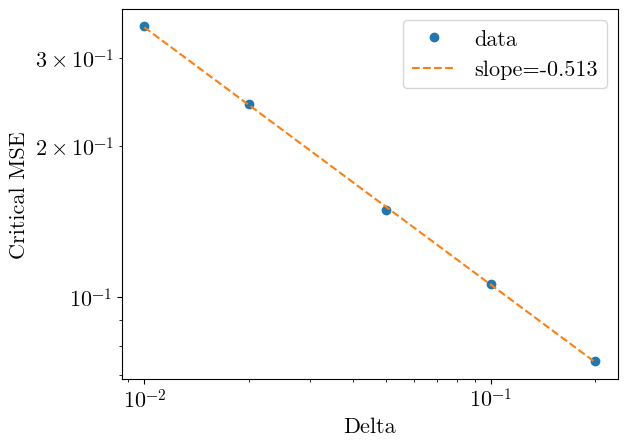

In [22]:
nu = 0.45
degree = 8

xs = []
ys = []

for r in results:

    if (
        r["nu"] == nu
        and r["degree"] == degree
    ):
        xs.append(r["Delta"])
        ys.append(r["critical_mse"])

xs = np.array(xs)
ys = np.array(ys)

alpha, b = np.polyfit(
    np.log(xs),
    np.log(ys),
    1
)

fit_curve = np.exp(b) * xs**alpha

plt.figure()
plt.loglog(xs, ys, "o", label="data")
plt.loglog(
    xs,
    fit_curve,
    "--",
    label=f"slope={alpha:.3f}"
)
plt.xlabel("Delta")
plt.ylabel("Critical MSE")
plt.legend()
plt.show()

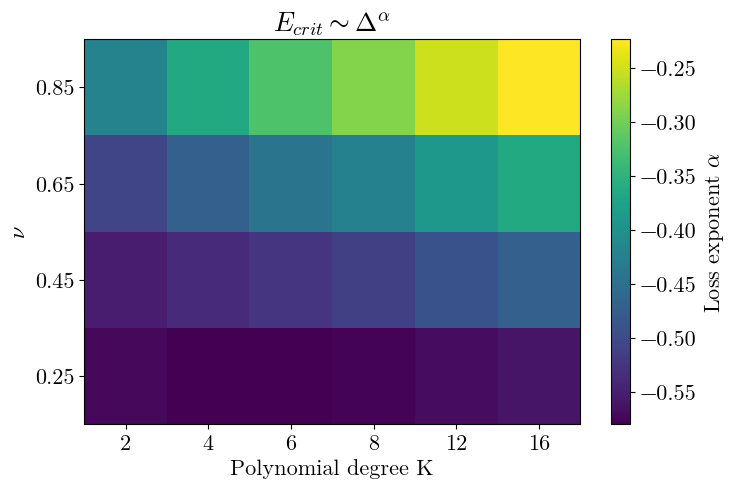

In [23]:

loss_exp = np.zeros(
    (len(nu_list), len(degree_list))
)

for i, nu in enumerate(nu_list):

    for j, degree in enumerate(degree_list):

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(r["critical_mse"])

        xs = np.array(xs)
        ys = np.array(ys)

        mask = ys > 0

        alpha, _ = np.polyfit(
            np.log(xs[mask]),
            np.log(ys[mask]),
            1
        )

        loss_exp[i, j] = alpha

plt.figure(figsize=(8,5))

im = plt.imshow(
    loss_exp,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    im,
    label=r"Loss exponent $\alpha$"
)

plt.xticks(
    np.arange(len(degree_list)),
    degree_list
)

plt.yticks(
    np.arange(len(nu_list)),
    nu_list
)

plt.xlabel("Polynomial degree K")
plt.ylabel(r"$\nu$")
plt.title(
    r"$E_{crit}\sim \Delta^\alpha$"
)

plt.show()

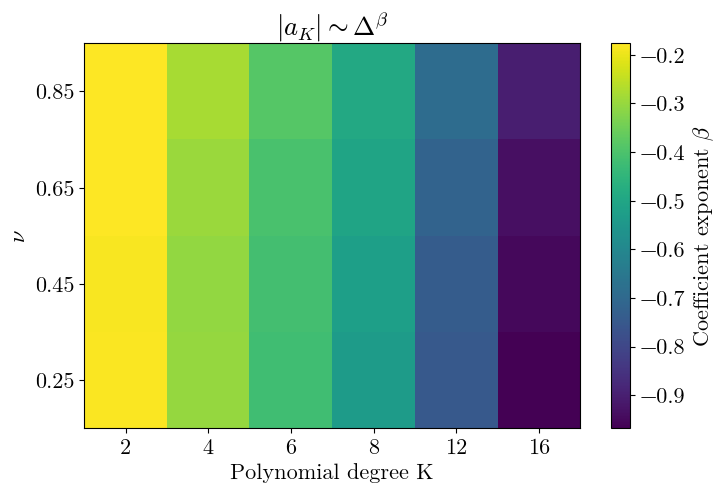

In [24]:
coeff_exp = np.zeros(
    (len(nu_list), len(degree_list))
)

for i, nu in enumerate(nu_list):

    for j, degree in enumerate(degree_list):

        xs = []
        ys = []

        for r in results:

            if (
                r["nu"] == nu
                and r["degree"] == degree
            ):
                xs.append(r["Delta"])
                ys.append(
                    abs(r["leading_coeff"])
                )

        xs = np.array(xs)
        ys = np.array(ys)

        mask = ys > 0

        beta, _ = np.polyfit(
            np.log(xs[mask]),
            np.log(ys[mask]),
            1
        )

        coeff_exp[i, j] = beta

plt.figure(figsize=(8,5))

im = plt.imshow(
    coeff_exp,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    im,
    label=r"Coefficient exponent $\beta$"
)

plt.xticks(
    np.arange(len(degree_list)),
    degree_list
)

plt.yticks(
    np.arange(len(nu_list)),
    nu_list
)

plt.xlabel("Polynomial degree K")
plt.ylabel(r"$\nu$")
plt.title(
    r"$|a_K|\sim \Delta^\beta$"
)

plt.show()